# 🗑️ Predicting Waste Generation in Neighborhoods
### SEED ML Internship — Project 4 | Cameroon, North-West Region

**Goal:** Build a model that predicts how many kg of waste a neighborhood will generate per week.

**Why?** Waste trucks currently run on fixed schedules — wasting fuel. With predictions, trucks only go when needed.

---
### 📌 Steps We Will Follow:
1. Import libraries (our tools)
2. Load and explore the data
3. Visualize patterns with charts
4. Prepare data for machine learning
5. Train 3 models and compare them
6. Save the best model
7. Make a sample prediction

---
## 📦 STEP 1: Import Libraries
Libraries are like toolboxes. We import them at the top so we can use their functions throughout the notebook.

In [1]:
# pandas helps us load, view, and manipulate data in table form (like Excel)
import pandas as pd

# numpy gives us math tools like square root, arrays, etc.
import numpy as np

# matplotlib is the main library for drawing charts and graphs
import matplotlib.pyplot as plt

# seaborn makes prettier charts, built on top of matplotlib
import seaborn as sns

# train_test_split splits our data into training and testing sets
from sklearn.model_selection import train_test_split

# LinearRegression is the simplest ML model — fits a straight line through data
from sklearn.linear_model import LinearRegression

# RandomForestRegressor builds many decision trees and averages their results
# GradientBoostingRegressor builds trees one by one, each correcting the previous
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# These metrics help us measure how good or bad our model's predictions are
# mean_absolute_error = average of |actual - predicted|
# mean_squared_error  = average of (actual - predicted) squared
# r2_score = how well model explains the data (0 to 1, higher is better)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# LabelEncoder converts text labels (like neighborhood names) into numbers
# ML models only understand numbers, not words
from sklearn.preprocessing import LabelEncoder

# joblib saves our trained model to a file so we can reuse it later
import joblib

# warnings is a built-in Python module
import warnings
warnings.filterwarnings('ignore')  # Tell Python to hide all warning messages

# Confirm everything loaded without errors
print('All libraries imported successfully!')

All libraries imported successfully!


---
## 📂 STEP 2: Load and Explore the Data
Before building any model, we must understand our data. This is called **EDA (Exploratory Data Analysis)**.

In [2]:
# pd.read_csv() reads a CSV file and stores it as a DataFrame (like a table)
# Make sure the CSV file is in the same folder as this notebook
df = pd.read_csv('project4_waste_generation.csv')

# .head(5) shows the first 5 rows so we can see what the data looks like
print('First 5 rows of the dataset:')
df.head(5)

First 5 rows of the dataset:


,Week_Start_Date,Neighborhood,Population_Density_per_km2,Number_of_Businesses,Avg_Household_Size,Market_Present,Industrial_Zone,Collection_Frequency_per_Week,Month,Weekly_Waste_Weight_kg
0,2020-01-06,Bambili,4432,432,8.3,0,0,1,1,2736.7
1,2020-01-13,Bambili,4403,428,8.4,0,0,1,1,2407.3
2,2020-01-20,Bambili,4360,427,8.3,0,0,1,1,2346.0
3,2020-01-27,Bambili,4373,433,8.4,0,0,1,1,2831.3
4,2020-02-03,Bambili,4352,426,7.7,0,0,1,2,2688.3


In [3]:
# df.shape returns a tuple: (number_of_rows, number_of_columns)
print(f'Dataset has {df.shape[0]} rows and {df.shape[1]} columns')

# .nunique() counts how many unique/different values exist in a column
print(f'Total unique neighborhoods: {df["Neighborhood"].nunique()}')

# .min() and .max() return the smallest and largest values in a column
print(f'Date range: {df["Week_Start_Date"].min()}  to  {df["Week_Start_Date"].max()}')

# .unique() returns an array of all different values in a column
print(f'\nAll neighborhoods in dataset:')
print(df['Neighborhood'].unique())

Dataset has 10000 rows and 10 columns
Total unique neighborhoods: 50
Date range: 2020-01-06  to  2024-10-07

All neighborhoods in dataset:
['Bambili' 'Up-Station' 'Nkwen' 'Mankon' 'Chomba' 'Awing' 'Bafut'
 'Mendankwe' 'Akum' 'Mbengwi' 'Bamenda City Centre' 'Old Town' 'Mile 4'
 'Mile 8' 'Ngomgham' 'Mulang' 'Azire' 'Atuazire' 'Nkwen Extension'
 'Ntaghem' 'Guzang' 'Fundong' 'Wum' 'Ndop' 'Kumbo' 'Nso' 'Oku' 'Jakiri'
 'Misaje' 'Mme' 'Balikumbat' 'Sabga' 'Bali' 'Batibo' 'Widikum' 'Esu' 'Nwa'
 'Furu-Awa' 'Ako' 'Nkambe' 'Njinikom' 'Belo' 'Boyo' 'Menchum'
 'Donga Mantung' 'Ngomgham South' 'Mile 6' 'Nitop' 'Bamenda Industrial'
 'Abakwa']


In [4]:
# .info() shows column names, data types, and count of non-null (non-missing) values
# dtype int64 = whole number | float64 = decimal number | object = text
print('Dataset column types and non-null counts:')
df.info()

Dataset column types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Week_Start_Date                10000 non-null  object 
 1   Neighborhood                   10000 non-null  object 
 2   Population_Density_per_km2     10000 non-null  int64  
 3   Number_of_Businesses           10000 non-null  int64  
 4   Avg_Household_Size             10000 non-null  float64
 5   Market_Present                 10000 non-null  int64  
 6   Industrial_Zone                10000 non-null  int64  
 7   Collection_Frequency_per_Week  10000 non-null  int64  
 8   Month                          10000 non-null  int64  
 9   Weekly_Waste_Weight_kg         10000 non-null  float64
dtypes: float64(2), int64(6), object(2)
memory usage: 781.4+ KB


In [5]:
# .isnull() returns True for every cell that has a missing value
# .sum() counts how many True values are in each column
print('Missing values per column:')
print(df.isnull().sum())

# .sum().sum() adds up ALL missing values across the whole table
total_missing = df.isnull().sum().sum()

# If total_missing is 0, data is clean. Otherwise we need to handle it.
if total_missing == 0:
    print('\nNo missing values found. Data is clean!')
else:
    print(f'\nWarning: {total_missing} missing values found!')

Missing values per column:
Week_Start_Date                  0
Neighborhood                     0
Population_Density_per_km2       0
Number_of_Businesses             0
Avg_Household_Size               0
Market_Present                   0
Industrial_Zone                  0
Collection_Frequency_per_Week    0
Month                            0
Weekly_Waste_Weight_kg           0
dtype: int64

No missing values found. Data is clean!


In [6]:
# .describe() gives a statistical summary of all numeric columns:
# count = total non-null values
# mean  = average value
# std   = standard deviation (how spread out the values are)
# min   = smallest value
# 25%   = 25th percentile (bottom quarter)
# 50%   = median (middle value)
# 75%   = 75th percentile (top quarter)
# max   = largest value
# .round(2) rounds all numbers to 2 decimal places
print('Statistical summary:')
df.describe().round(2)

Statistical summary:


,Population_Density_per_km2,Number_of_Businesses,Avg_Household_Size,Market_Present,Industrial_Zone,Collection_Frequency_per_Week,Month,Weekly_Waste_Weight_kg
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,2477.74,282.96,6.01,0.60,0.28,1.96,6.48,2103.63
std,1222.47,174.49,1.48,0.49,0.45,0.77,3.45,690.01
min,198.00,8.00,2.90,0.00,0.00,1.00,1.00,736.30
25%,1444.00,123.00,4.70,0.00,0.00,1.00,4.00,1581.72
50%,2567.00,298.00,6.10,1.00,0.00,2.00,7.00,2072.70
75%,3515.00,426.00,7.20,1.00,1.00,3.00,10.00,2582.12
max,4502.00,569.00,9.10,1.00,1.00,3.00,12.00,4603.70


---
## 📊 STEP 3: Visualize the Data
Charts help us see patterns and understand the data before we build the model.

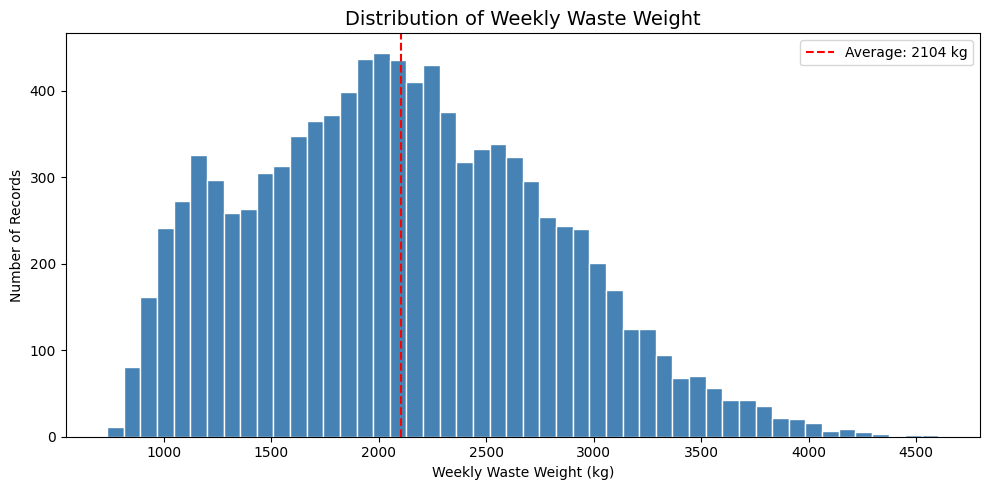

Average weekly waste across all neighborhoods: 2103.6 kg


In [7]:
# ── CHART 1: Distribution of Weekly Waste Weight ──────────────────────────────

# plt.figure() creates a blank canvas for our chart
# figsize=(width, height) sets the size in inches
plt.figure(figsize=(10, 5))

# plt.hist() draws a histogram showing how values are spread out
# bins=50 means we divide the data into 50 equal buckets along the x-axis
# color sets the bar fill color, edgecolor adds a border around each bar
plt.hist(df['Weekly_Waste_Weight_kg'], bins=50, color='steelblue', edgecolor='white')

# Add a title and axis labels so readers understand what they are looking at
plt.title('Distribution of Weekly Waste Weight', fontsize=14)
plt.xlabel('Weekly Waste Weight (kg)')  # x-axis label
plt.ylabel('Number of Records')         # y-axis label

# Calculate the average (mean) waste value
avg_waste = df['Weekly_Waste_Weight_kg'].mean()

# plt.axvline() draws a vertical line at the average value
# linestyle='--' makes it dashed, label= adds text to the legend
plt.axvline(avg_waste, color='red', linestyle='--', label=f'Average: {avg_waste:.0f} kg')

# plt.legend() displays the labels we defined above
plt.legend()

# plt.tight_layout() adjusts spacing so nothing gets cut off
plt.tight_layout()

# plt.show() renders and displays the chart
plt.show()

print(f'Average weekly waste across all neighborhoods: {avg_waste:.1f} kg')

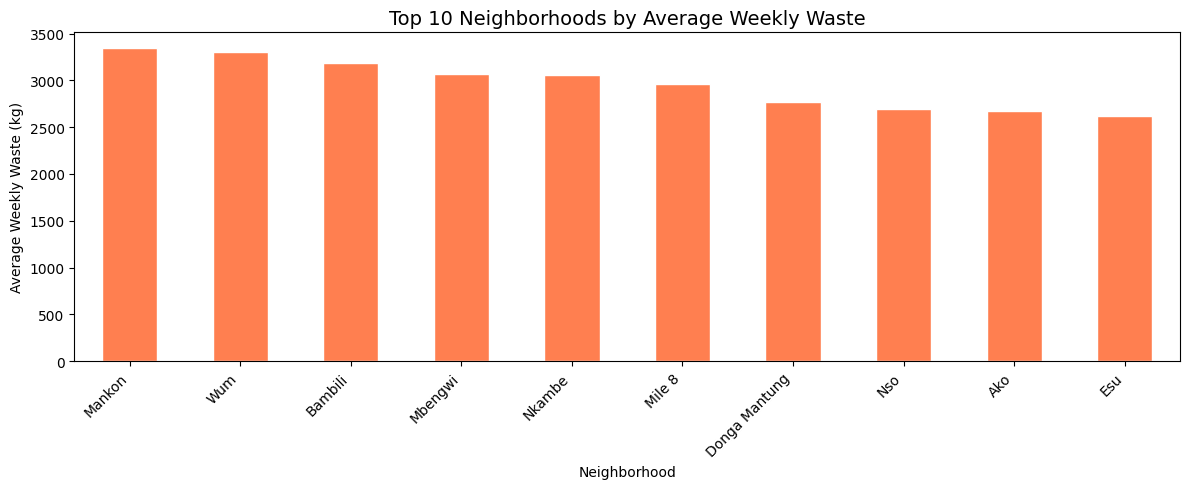

In [8]:
# ── CHART 2: Top 10 Neighborhoods by Average Waste ───────────────────────────

# .groupby('Neighborhood') groups all rows that share the same neighborhood name
# ['Weekly_Waste_Weight_kg'].mean() calculates the average waste for each group
# .sort_values(ascending=False) sorts from highest to lowest average waste
# .head(10) keeps only the top 10 results
top10 = df.groupby('Neighborhood')['Weekly_Waste_Weight_kg'].mean()\
          .sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))

# .plot(kind='bar') draws a bar chart directly from a pandas Series
# edgecolor='white' adds a white border between bars
top10.plot(kind='bar', color='coral', edgecolor='white')

plt.title('Top 10 Neighborhoods by Average Weekly Waste', fontsize=14)
plt.xlabel('Neighborhood')
plt.ylabel('Average Weekly Waste (kg)')

# rotation=45 tilts x-axis labels 45 degrees so they don't overlap
# ha='right' aligns the labels to the right side of each tick
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

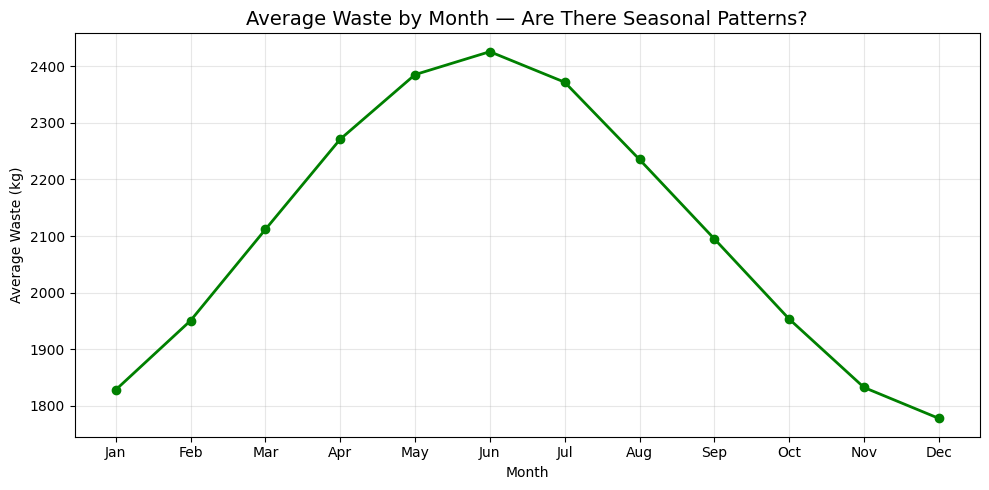

In [9]:
# ── CHART 3: Waste by Month (Seasonal Trend) ─────────────────────────────────

# Group by month number (1–12) and calculate average waste per month
monthly_avg = df.groupby('Month')['Weekly_Waste_Weight_kg'].mean()

# Short month names for the x-axis labels
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 5))

# plt.plot() draws a line chart connecting data points
# marker='o' places a circle at each data point
# linewidth=2 makes the line a bit thicker
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='green', linewidth=2)

# Replace x-axis numbers (1–12) with actual month names
plt.xticks(range(1, 13), month_names)

plt.title('Average Waste by Month — Are There Seasonal Patterns?', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Waste (kg)')

# alpha=0.3 makes grid lines faint (0 = invisible, 1 = solid)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

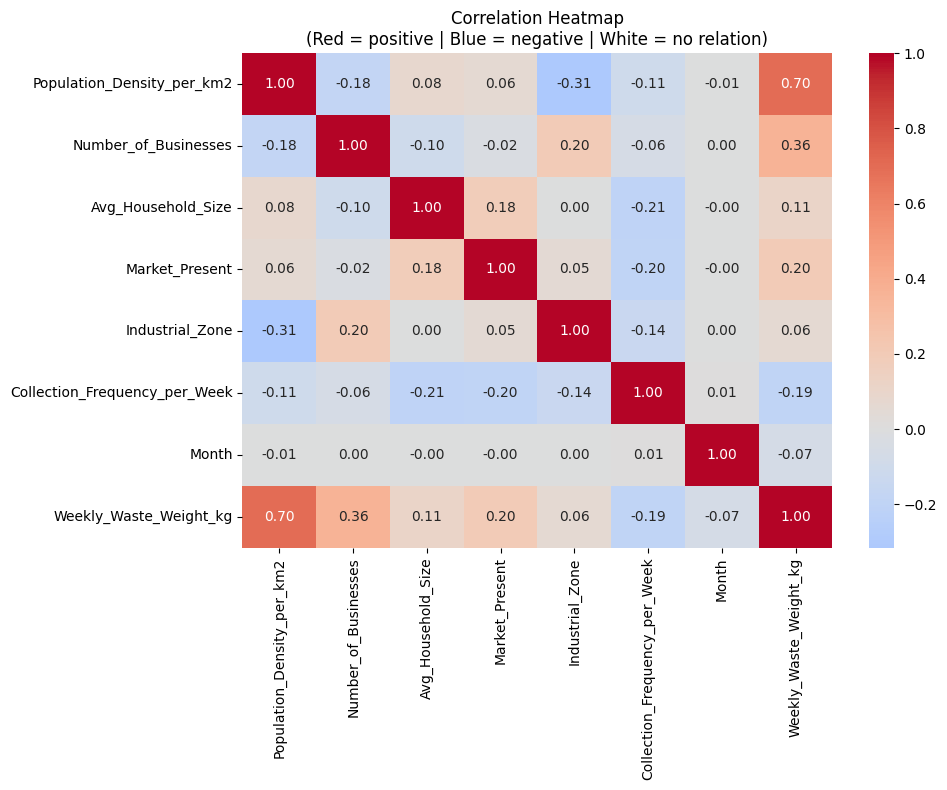

In [10]:
# ── CHART 4: Correlation Heatmap ─────────────────────────────────────────────
# Correlation measures how strongly two variables move together:
#   +1 = when one goes up, the other always goes up too
#   -1 = when one goes up, the other always goes down
#    0 = no relationship at all

# Select only the numeric columns we care about
numeric_cols = [
    'Population_Density_per_km2',
    'Number_of_Businesses',
    'Avg_Household_Size',
    'Market_Present',
    'Industrial_Zone',
    'Collection_Frequency_per_Week',
    'Month',
    'Weekly_Waste_Weight_kg'   # this is what we want to predict
]

# .corr() calculates correlation between every pair of columns
# The result is a square matrix (table) of values between -1 and +1
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

# sns.heatmap() draws a color-coded grid of the correlation values
# annot=True prints the actual numbers inside each cell
# fmt='.2f' formats numbers to 2 decimal places
# cmap='coolwarm' uses blue for negative and red for positive correlations
# center=0 means pure white = zero correlation
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Correlation Heatmap\n(Red = positive | Blue = negative | White = no relation)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 🔧 STEP 4: Prepare Data for Machine Learning
ML models can only work with numbers. We need to:
- Convert text (neighborhood names) into numbers
- Choose **input features (X)** and **target variable (y)**
- Split data into a **training set** and a **testing set**

In [11]:
# ── Encode Neighborhood Names as Numbers ─────────────────────────────────────

# Create a LabelEncoder object
le = LabelEncoder()

# .fit_transform() does two things at once:
#   fit      = scans the column and learns all unique neighborhood names
#   transform = replaces each name with its assigned number (alphabetical order)
# Example: 'Abakwa' → 0, 'Ako' → 1, 'Akum' → 2, 'Awing' → 3, ...
df['Neighborhood_Encoded'] = le.fit_transform(df['Neighborhood'])

# le.classes_ stores the original names in the order they were encoded
# Let's print the first 5 to verify the encoding worked correctly
print('Encoding preview (first 5 neighborhoods):')
for i, name in enumerate(le.classes_[:5]):
    print(f'  {name}  →  {i}')

Encoding preview (first 5 neighborhoods):
  Abakwa  →  0
  Ako  →  1
  Akum  →  2
  Atuazire  →  3
  Awing  →  4


In [12]:
# ── Define Input Features (X) and Target Variable (y) ────────────────────────

# features = the list of columns we give the model to learn from (inputs)
# We picked these based on the project description and what we saw in EDA
features = [
    'Population_Density_per_km2',    # how crowded the area is
    'Number_of_Businesses',           # how many shops/offices/restaurants exist
    'Avg_Household_Size',             # average number of people per home
    'Market_Present',                 # 1 = market exists, 0 = no market
    'Industrial_Zone',                # 1 = industrial area, 0 = not industrial
    'Collection_Frequency_per_Week',  # how often waste trucks come
    'Month',                          # month number: 1 = January, 12 = December
    'Neighborhood_Encoded'            # neighborhood converted to a number
]

# X = all the input columns the model will use to make predictions
# df[features] selects only the columns listed in the features list
X = df[features]

# y = the target column: what we want the model to predict
# This is a single column of numbers (the weekly waste weight)
y = df['Weekly_Waste_Weight_kg']

# Print shapes to confirm they look right
print(f'X (inputs) shape:  {X.shape}  →  {X.shape[0]} rows, {X.shape[1]} columns')
print(f'y (target) shape:  {y.shape}  →  {y.shape[0]} values to predict')

X (inputs) shape:  (10000, 8)  →  10000 rows, 8 columns
y (target) shape:  (10000,)  →  10000 values to predict


In [13]:
# ── Split into Training and Testing Sets ─────────────────────────────────────

# We split the data so the model cannot cheat by memorizing test answers
# It learns from the training set and is tested on data it has never seen

# train_test_split() randomly shuffles and splits the data
#   test_size=0.2   → 20% of rows go to testing, 80% go to training
#   random_state=42 → sets a random seed so we get the same split every run
#                     (any number works, 42 is just a popular choice)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Training rows: {X_train.shape[0]}  (model learns from these)')
print(f'Testing rows:  {X_test.shape[0]}   (we check accuracy on these)')
print('\nThink of it like: training = studying, testing = the real exam!')

Training rows: 8000  (model learns from these)
Testing rows:  2000   (we check accuracy on these)

Think of it like: training = studying, testing = the real exam!


---
## 🤖 STEP 5: Train the Models

We train 3 models and compare which one predicts best.

| Model | Simple explanation |
|-------|-------------------|
| Linear Regression | Draws the best straight line through the data |
| Random Forest | Builds 100 decision trees and averages their answers |
| Gradient Boosting | Builds trees in a chain, each one fixing the last one's mistakes |

In [14]:
# ── Helper Function to Evaluate Any Model ────────────────────────────────────
# Writing this once means we don't have to repeat the same code 3 times

def evaluate_model(model_name, model, X_test, y_test):
    # .predict() feeds the test features into the trained model
    # and returns an array of predicted waste values
    predictions = model.predict(X_test)

    # MAE = Mean Absolute Error
    # Average of |actual_value - predicted_value| across all test rows
    # Tells us: on average, how many kg off are our predictions?
    mae = mean_absolute_error(y_test, predictions)

    # RMSE = Root Mean Squared Error
    # Similar to MAE but punishes large errors more heavily
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    # R² (R-squared) = coefficient of determination
    # 0.0 = model explains nothing | 1.0 = perfect predictions
    # 0.91 means the model explains 91% of the variation in waste
    r2 = r2_score(y_test, predictions)

    # Print all three metrics
    print(f'\n{model_name} Results:')
    print(f'  MAE  = {mae:.1f} kg   (avg prediction error — lower is better)')
    print(f'  RMSE = {rmse:.1f} kg  (penalizes big errors — lower is better)')
    print(f'  R²   = {r2:.4f}       (accuracy score — closer to 1.0 is better)')

    # Return a dictionary so we can use the values later for comparison charts
    return {'name': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'preds': predictions}

print('evaluate_model() function is ready!')

evaluate_model() function is ready!


In [15]:
# ── MODEL 1: Linear Regression ────────────────────────────────────────────────
# The simplest regression model
# It finds a straight line that best fits all data points
# We use this as a baseline to compare with more complex models

print('Training Model 1: Linear Regression...')

# Create the model object (this just defines the type of model, nothing is trained yet)
lr_model = LinearRegression()

# .fit() is where the actual learning happens
# The model reads X_train (features) and y_train (actual waste values)
# and finds the best mathematical formula to connect them
lr_model.fit(X_train, y_train)

# Evaluate and store results
lr_results = evaluate_model('Linear Regression', lr_model, X_test, y_test)

print('\nLinear Regression training complete!')

Training Model 1: Linear Regression...

Linear Regression Results:
  MAE  = 228.1 kg   (avg prediction error — lower is better)
  RMSE = 288.8 kg  (penalizes big errors — lower is better)
  R²   = 0.8258       (accuracy score — closer to 1.0 is better)

Linear Regression training complete!


In [17]:
# ── MODEL 2: Random Forest ────────────────────────────────────────────────────
# Builds many decision trees and combines their predictions
# Usually much better than Linear Regression on real-world data

print('Training Model 2: Random Forest... (may take 30–60 seconds)')

# n_estimators=100  → create 100 decision trees in the forest
#                     more trees = more accurate but slower to train
# random_state=42   → ensures same trees are built every run (reproducibility)
# n_jobs=-1         → use all available CPU cores to speed up training
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# .fit() trains all 100 decision trees on the training data
rf_model.fit(X_train, y_train)

# Evaluate and store results
rf_results = evaluate_model('Random Forest', rf_model, X_test, y_test)

print('\nRandom Forest training complete!')

Training Model 2: Random Forest... (may take 30–60 seconds)

Random Forest Results:
  MAE  = 161.0 kg   (avg prediction error — lower is better)
  RMSE = 210.6 kg  (penalizes big errors — lower is better)
  R²   = 0.9074       (accuracy score — closer to 1.0 is better)

Random Forest training complete!


In [18]:
# ── MODEL 3: Gradient Boosting ────────────────────────────────────────────────
# Builds decision trees one by one in a sequence
# Each new tree focuses on correcting the errors made by the previous tree
# Often very accurate, but takes longer than Random Forest

print('Training Model 3: Gradient Boosting... (may take a minute or two)')

# n_estimators=100  → build 100 trees in sequence (boosting stages)
# random_state=42   → for reproducibility
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

# .fit() trains the boosted model on the training data
gb_model.fit(X_train, y_train)

# Evaluate and store results
gb_results = evaluate_model('Gradient Boosting', gb_model, X_test, y_test)

print('\nGradient Boosting training complete!')

Training Model 3: Gradient Boosting... (may take a minute or two)

Gradient Boosting Results:
  MAE  = 148.5 kg   (avg prediction error — lower is better)
  RMSE = 193.6 kg  (penalizes big errors — lower is better)
  R²   = 0.9217       (accuracy score — closer to 1.0 is better)

Gradient Boosting training complete!


---
## 🏆 STEP 6: Compare Models and Pick the Best

In [19]:
# ── Build a Comparison Table ──────────────────────────────────────────────────

# Create a list of dictionaries — one dictionary per model
# Each dictionary holds the model name and its three performance scores
comparison_data = [
    {'Model': 'Linear Regression',
     'MAE (kg)':  round(lr_results['MAE'], 1),
     'RMSE (kg)': round(lr_results['RMSE'], 1),
     'R² Score':  round(lr_results['R2'], 4)},

    {'Model': 'Random Forest',
     'MAE (kg)':  round(rf_results['MAE'], 1),
     'RMSE (kg)': round(rf_results['RMSE'], 1),
     'R² Score':  round(rf_results['R2'], 4)},

    {'Model': 'Gradient Boosting',
     'MAE (kg)':  round(gb_results['MAE'], 1),
     'RMSE (kg)': round(gb_results['RMSE'], 1),
     'R² Score':  round(gb_results['R2'], 4)},
]

# Convert the list of dictionaries to a DataFrame so it prints as a nice table
comparison_df = pd.DataFrame(comparison_data)

print('MODEL COMPARISON TABLE')
print('Lower MAE/RMSE = better | Higher R² = better')
print()

# .to_string(index=False) prints the table without the row index numbers
print(comparison_df.to_string(index=False))

MODEL COMPARISON TABLE
Lower MAE/RMSE = better | Higher R² = better

            Model  MAE (kg)  RMSE (kg)  R² Score
Linear Regression     228.1      288.8    0.8258
    Random Forest     161.0      210.6    0.9074
Gradient Boosting     148.5      193.6    0.9217


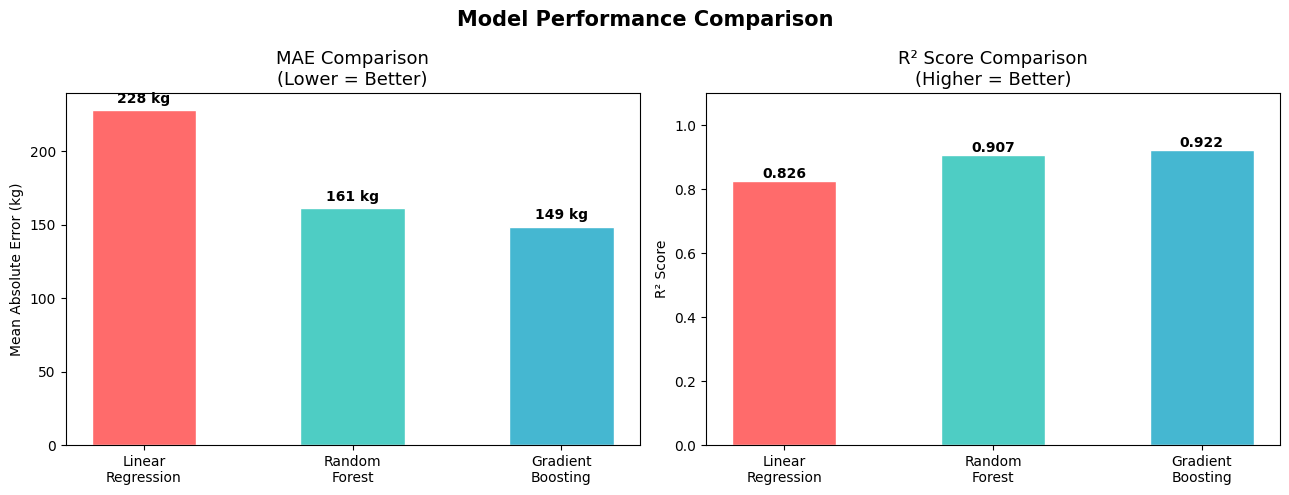

In [20]:
# ── Side-by-Side Bar Charts for Model Comparison ─────────────────────────────

# plt.subplots(1, 2) creates a figure with 1 row and 2 side-by-side charts
# axes is a list: axes[0] = left chart, axes[1] = right chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Data values for the bar charts
model_labels = ['Linear\nRegression', 'Random\nForest', 'Gradient\nBoosting']
mae_values   = [lr_results['MAE'],  rf_results['MAE'],  gb_results['MAE']]
r2_values    = [lr_results['R2'],   rf_results['R2'],   gb_results['R2']]

# Each bar gets a different color for easy reading
bar_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# ── Left chart: MAE (lower = better) ──
axes[0].bar(model_labels, mae_values, color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_title('MAE Comparison\n(Lower = Better)', fontsize=13)
axes[0].set_ylabel('Mean Absolute Error (kg)')

# Add a value label on top of each bar using a for loop
# enumerate() gives us both the index (i) and value (val) at the same time
for i, val in enumerate(mae_values):
    axes[0].text(i, val + 5, f'{val:.0f} kg', ha='center', fontweight='bold')

# ── Right chart: R² (higher = better) ──
axes[1].bar(model_labels, r2_values, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_title('R² Score Comparison\n(Higher = Better)', fontsize=13)
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.1)  # Set y-axis to run from 0 to 1.1 for clear comparison

# Add value labels on top of each bar
for i, val in enumerate(r2_values):
    axes[1].text(i, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold')

# Add an overall title above both charts
plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

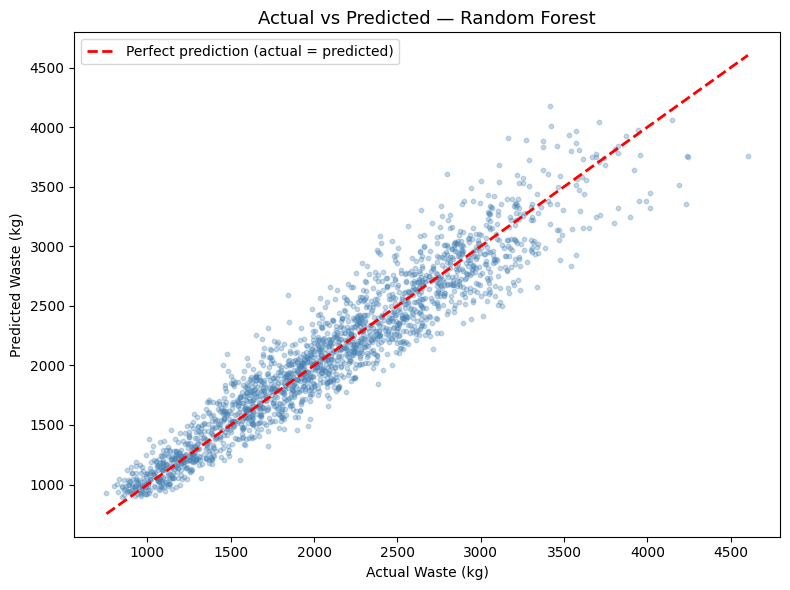

The closer the dots are to the red line, the more accurate the model!


In [21]:
# ── Actual vs Predicted Scatter Plot ─────────────────────────────────────────
# Shows how close the Random Forest predictions are to the real values
# If a dot is ON the red line, the prediction was exactly right

plt.figure(figsize=(8, 6))

# Scatter plot: x = actual values, y = what the model predicted
# alpha=0.3 makes dots semi-transparent so we can see overlapping points
# s=10 makes dots small to reduce clutter
plt.scatter(y_test, rf_results['preds'], alpha=0.3, color='steelblue', s=10)

# Draw the perfect prediction line (where actual = predicted)
# [y_test.min(), y_test.max()] gives us the range along both axes
# 'r--' = red dashed line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Perfect prediction (actual = predicted)'
)

plt.xlabel('Actual Waste (kg)')
plt.ylabel('Predicted Waste (kg)')
plt.title('Actual vs Predicted — Random Forest', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print('The closer the dots are to the red line, the more accurate the model!')

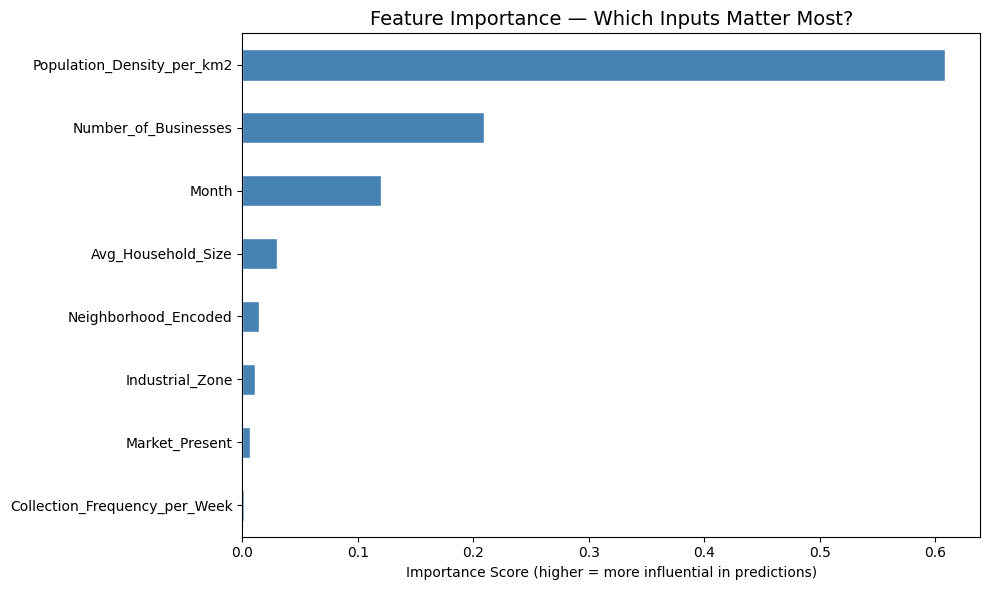

Top 3 most important features:
  Population_Density_per_km2: 0.6085
  Number_of_Businesses: 0.2090
  Month: 0.1196


In [22]:
# ── Feature Importance Chart ──────────────────────────────────────────────────
# Random Forest can tell us how much each input feature influenced predictions
# Higher importance score = that feature had more effect on the output

# .feature_importances_ is an attribute of a trained RandomForest model
# It is an array of values that add up to 1.0
# pd.Series() pairs each importance score with its feature name
importances = pd.Series(
    rf_model.feature_importances_,  # array of importance scores
    index=features                  # match each score to its feature name
).sort_values(ascending=True)       # sort ascending so longest bar is on top

plt.figure(figsize=(10, 6))

# kind='barh' draws horizontal bars (easier to read long feature names)
importances.plot(kind='barh', color='steelblue', edgecolor='white')

plt.title('Feature Importance — Which Inputs Matter Most?', fontsize=14)
plt.xlabel('Importance Score (higher = more influential in predictions)')
plt.tight_layout()
plt.show()

# Print the top 3 most important features
print('Top 3 most important features:')
for feat, score in importances.sort_values(ascending=False).head(3).items():
    print(f'  {feat}: {score:.4f}')

---
## 💾 STEP 7: Save the Best Model

In [23]:
# ── Save Model and Encoder to Files ──────────────────────────────────────────

# joblib.dump() serializes (converts) a Python object to a binary .pkl file
# This preserves everything about the trained model — all trees, all split rules
# Later, joblib.load() can restore it exactly as it was

# Save the trained Random Forest model
# The Streamlit app will load this file to make predictions
joblib.dump(rf_model, 'waste_model.pkl')

# Save the LabelEncoder too
# We need it to convert neighborhood names into numbers in the app
# Without it, we cannot encode new input from users
joblib.dump(le, 'label_encoder.pkl')

print('Model saved as: waste_model.pkl')
print('Label encoder saved as: label_encoder.pkl')
print('\nBoth files must be in the same folder as waste_app.py')

Model saved as: waste_model.pkl
Label encoder saved as: label_encoder.pkl

Both files must be in the same folder as waste_app.py


---
## 🔮 STEP 8: Make a Sample Prediction

In [24]:
# ── Load the Saved Model and Make a Real Prediction ──────────────────────────

# joblib.load() reads the .pkl file and restores the saved Python object
# This is exactly what the Streamlit app does when it first starts
loaded_model   = joblib.load('waste_model.pkl')
loaded_encoder = joblib.load('label_encoder.pkl')

print('Model and encoder loaded from file.')

# Choose a neighborhood to predict for
neighborhood_name = 'Bambili'

# .transform([neighborhood_name]) converts the name to its encoded number
# It returns an array like [4], so [0] extracts just the integer value
neighborhood_code = loaded_encoder.transform([neighborhood_name])[0]

# Build the input as a single-row DataFrame
# pd.DataFrame([{...}]) wraps a dictionary inside a DataFrame with 1 row
# Column order MUST match the order used during training
sample_input = pd.DataFrame([{
    'Population_Density_per_km2':    4400,  # persons per km²
    'Number_of_Businesses':           430,  # number of businesses
    'Avg_Household_Size':             8.2,  # average people per household
    'Market_Present':                   0,  # 0 = no market
    'Industrial_Zone':                  0,  # 0 = not industrial
    'Collection_Frequency_per_Week':    1,  # 1 pickup per week
    'Month':                            3,  # 3 = March
    'Neighborhood_Encoded': neighborhood_code  # Bambili as a number
}])

# .predict() runs the input through all 100 trees and returns their average
# [0] extracts the single predicted value from the result array
predicted_waste = loaded_model.predict(sample_input)[0]

# Estimate how many trucks to send
# Assuming one truck carries 1500 kg
# round() rounds to nearest whole number, max(1,...) ensures at least 1 truck
trucks_needed = max(1, round(predicted_waste / 1500))

# Print the final results
print(f'\nNeighborhood: {neighborhood_name}')
print(f'Month: March')
print(f'Predicted weekly waste: {predicted_waste:.1f} kg')
print(f'Trucks to send: {trucks_needed}')

Model and encoder loaded from file.

Neighborhood: Bambili
Month: March
Predicted weekly waste: 3036.7 kg
Trucks to send: 2


---
## 🎉 You Are Done!

| Step | What you did |
|------|--------------|
| 1 | Imported all Python libraries |
| 2 | Loaded and explored 10,000 rows of waste data |
| 3 | Visualized data with 4 charts |
| 4 | Prepared data: encoded text, split train/test |
| 5 | Trained 3 ML models |
| 6 | Compared models — Random Forest won (R² ≈ 0.91) |
| 7 | Saved the model and encoder to files |
| 8 | Made a sample prediction |

**Next step:** Run `streamlit run waste_app.py` to launch the interactive web app!